In [6]:
import pandas as pd

data = {
    "StudyHours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Attendance": [45, 50, 55, 60, 65, 70, 75, 80, 85, 90],
    "PreviousMarks": [40, 45, 50, 55, 60, 65, 70, 75, 80, 85],
    "Pass": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

df

,StudyHours,Attendance,PreviousMarks,Pass
0,1,45,40,0
1,2,50,45,0
2,3,55,50,0
3,4,60,55,0
4,5,65,60,1
5,6,70,65,1
6,7,75,70,1
7,8,80,75,1
8,9,85,80,1
9,10,90,85,1


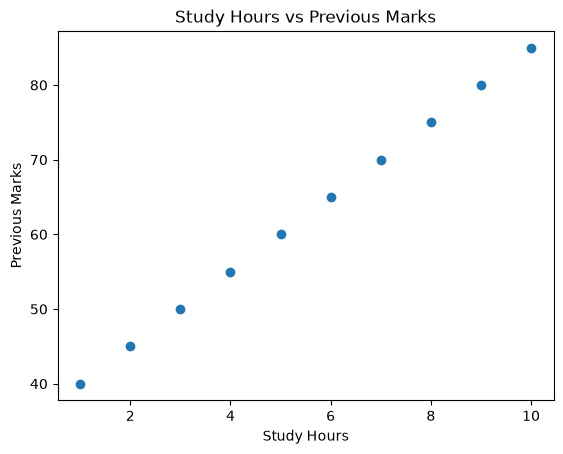

In [7]:
import matplotlib.pyplot as plt

plt.scatter(df["StudyHours"], df["PreviousMarks"])

plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")
plt.title("Study Hours vs Previous Marks")

plt.show()

In [8]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(10, 4)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   StudyHours     10 non-null     int64
 1   Attendance     10 non-null     int64
 2   PreviousMarks  10 non-null     int64
 3   Pass           10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes
None
StudyHours       0
Attendance       0
PreviousMarks    0
Pass             0
dtype: int64
       StudyHours  Attendance  PreviousMarks       Pass
count    10.00000   10.000000      10.000000  10.000000
mean      5.50000   67.500000      62.500000   0.600000
std       3.02765   15.138252      15.138252   0.516398
min       1.00000   45.000000      40.000000   0.000000
25%       3.25000   56.250000      51.250000   0.000000
50%       5.50000   67.500000      62.500000   1.000000
75%       7.75000   78.750000      73.750000   1.000000
max      10.00000   90.000000      85.000000   1.000000


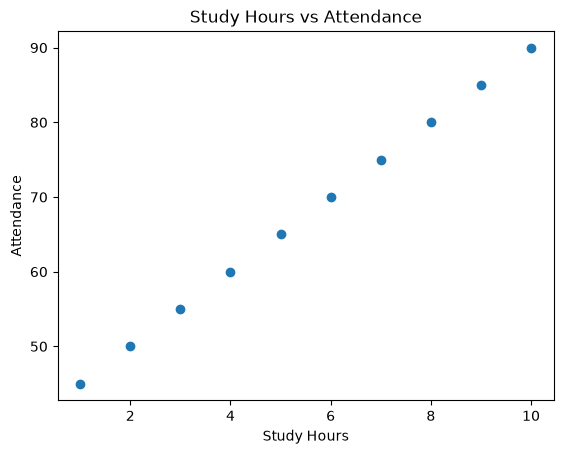

In [13]:
plt.scatter(df["StudyHours"], df["Attendance"])

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Study Hours vs Attendance")

plt.show()

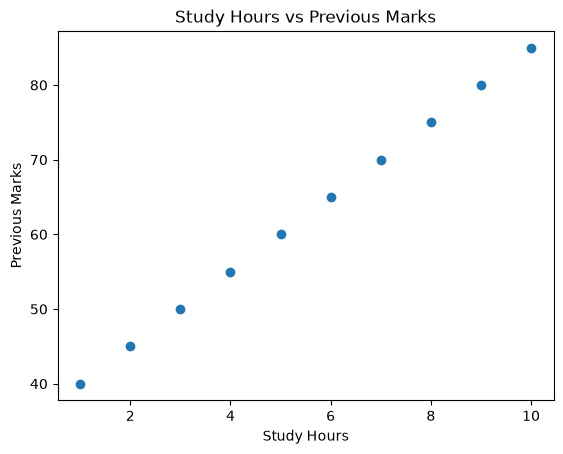

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df["StudyHours"], df["PreviousMarks"])
plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")
plt.title("Study Hours vs Previous Marks")
plt.show()

In [15]:
X = df[["StudyHours", "Attendance", "PreviousMarks"]]
Y = df["Pass"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [18]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

In [19]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(Y_test, y_pred)

results

{'Logistic Regression': 1.0,
 'KNN': 1.0,
 'Decision Tree': 1.0,
 'Random Forest': 1.0,
 'SVM': 1.0,
 'Naive Bayes': 1.0}

In [20]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, Y, cv=5, scoring="accuracy")
    cv_results[name] = scores.mean()

cv_results

C:\Users\ayan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\ayan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\ayan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\ayan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\ayan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.

{'Logistic Regression': np.float64(0.8),
 'KNN': np.float64(0.9),
 'Decision Tree': np.float64(0.9),
 'Random Forest': np.float64(0.9),
 'SVM': np.float64(0.9),
 'Naive Bayes': np.float64(0.9)}

In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))
print("Recall:", recall_score(Y_test, y_pred))
print("F1 Score:", f1_score(Y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)

print(cm)

[[1 0]
 [0 1]]


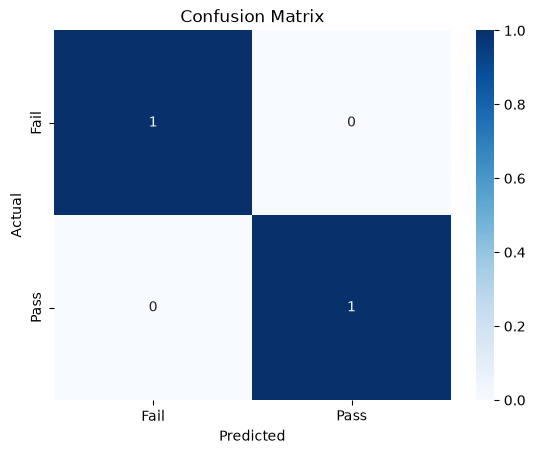

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [2, 3, 4, None]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X, Y)

C:\Users\ayan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inform

In [27]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 2, 'n_estimators': 50}
Best CV Score: 0.9


In [28]:
best_model = grid.best_estimator_

print(best_model)

RandomForestClassifier(max_depth=2, n_estimators=50, random_state=42)


In [29]:
new_student = [[6, 72, 68]]

prediction = best_model.predict(new_student)

print("Prediction:", prediction)

Prediction: [1]


C:\Users\ayan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [30]:
new_student = [[6, 72, 68]]

prediction = best_model.predict(new_student)

print("Prediction:", prediction)

Prediction: [1]


C:\Users\ayan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [32]:
if prediction[0] == 1:
    print("Student will PASS")
else:
    print("Student will FAIL")

Student will PASS


In [33]:
if prediction[0] == 1:
    print("student will pass")
else:
    print("student will Fail")

student will pass


In [34]:
import joblib

joblib.dump(best_model, "student_pass_fail_model.pkl")

['student_pass_fail_model.pkl']

In [36]:
loaded_model = joblib.load("student_pass_fail_model.pkl")

prediction = loaded_model.predict([[7, 80, 75]])

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Student will PASS")
else:
    print("Student will FAIL")

Prediction: [1]
Student will PASS


C:\Users\ayan_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [37]:
new_student = [[7, 80, 75]]

new_student_df = pd.DataFrame(
    new_student,
    columns=["StudyHours", "Attendance", "PreviousMarks"]
)

prediction = loaded_model.predict(new_student_df)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Student will PASS")
else:
    print("Student will FAIL")

Prediction: [1]
Student will PASS


In [29]:
import pandas as pd

In [ ]:
study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance: "))
previous_marks = float(input("Enter Previous Marks: "))

new_student = [[study_hours, attendance, previous_marks]]

new_student_df = pd.DataFrame(
    new_student,
    columns=["StudyHours", "Attendance", "PreviousMarks"]
)

prediction = loaded_model.predict(new_student_df)

if prediction[0] == 1:
    print("🎉 Student will PASS")
else:
    print("❌ Student will FAIL")